In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [4]:
url = 'https://github.com/BobAdamsEE/SouthParkData/blob/master/All-seasons.csv?raw=true'
df = pd.read_csv(url) #index_col=0
print(len(df))

70896


In [5]:
# get line lengths
df["line_len"] = df["Line"].str.split().str.len()
sorted = df.sort_values("line_len", ascending = False)

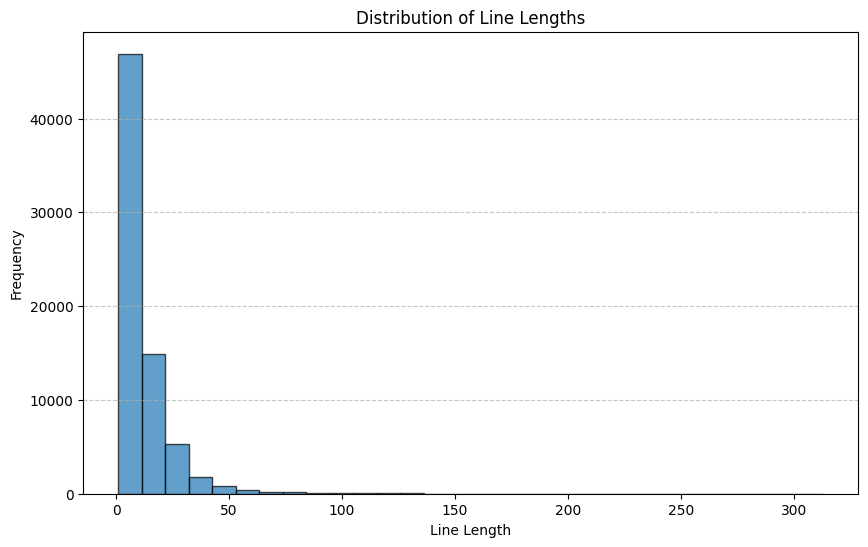

In [6]:
# plot histogram of line lengths
plt.figure(figsize=(10, 6))  # Set figure size
plt.hist(df["line_len"], bins=30, edgecolor='black', alpha=0.7)  # Adjust bins as needed
plt.xlabel("Line Length")
plt.ylabel("Frequency")
plt.title("Distribution of Line Lengths")
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid lines
plt.show()

In [21]:
# look at tokenized line length
tokenizer = AutoTokenizer.from_pretrained('Xuhui/ToxDect-roberta-large')

tokenized_lines = []

for line in df["Line"]:
    tl = tokenizer.tokenize(line)
    tokenized_lines.append(tl)

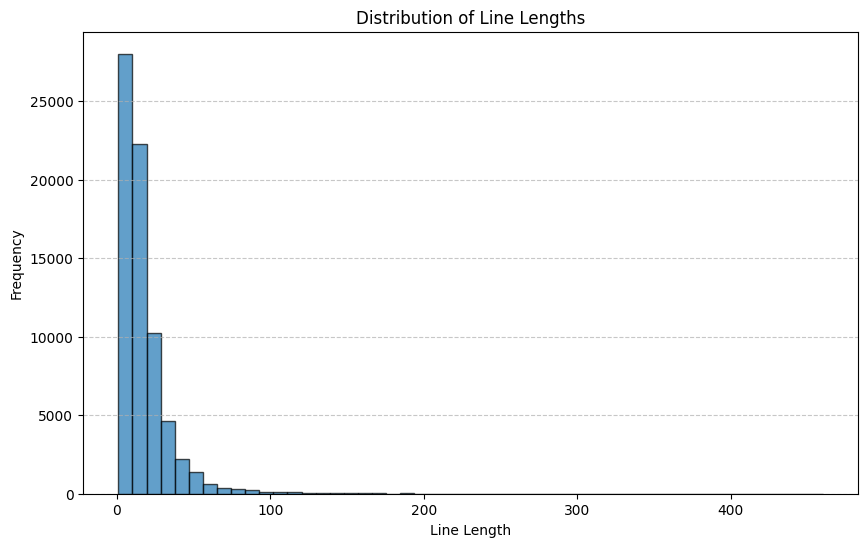

In [22]:
# plot histogram of tokenized line length
len_tls = [len(line) for line in tokenized_lines]
plt.figure(figsize=(10, 6))  # Set figure size
plt.hist(len_tls, bins=50, edgecolor='black', alpha=0.7)  # Adjust bins as needed
plt.xlabel("Line Length")
plt.ylabel("Frequency")
plt.title("Distribution of Line Lengths")
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid lines
plt.show()

In [28]:
df["token_line_len"] = len_tls
print(df["token_line_len"].quantile(0.995))

# 99.5% of the lines are under 115

115.0


In [31]:
batch = df[:1000]
print(max(batch["token_line_len"]))

185
